# 可选实验 - 简单神经网络
在本实验中，我们将使用Numpy构建一个小型神经网络。它将与你在TensorFlow中实现的 “咖啡烘焙” 网络相同。
   <center> <img  src="../work/images/C2_W1_CoffeeRoasting.png" width="400" />   <center/>


In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('./deeplearning.mplstyle')
import tensorflow as tf
from lab_utils_common import dlc, sigmoid
from lab_coffee_utils import load_coffee_data, plt_roast, plt_prob, plt_layer, plt_network, plt_output_unit
import logging
logging.getLogger("tensorflow").setLevel(logging.ERROR)
tf.autograph.set_verbosity(0)

## 数据集
这与上一个实验的数据集相同。

In [2]:
X,Y = load_coffee_data();
print(X.shape, Y.shape)

(200, 2) (200, 1)


让我们绘制以下咖啡烘焙数据。两个特征分别是摄氏温度和时长（单位：分钟）。[在家烘焙咖啡](https://www.merchantsofgreencoffee.com/how-to-roast-green-coffee-in-your-oven/)建议，时长最好保持在12到15分钟之间，而温度应在175到260摄氏度之间。当然，随着温度升高，时长应该缩短。

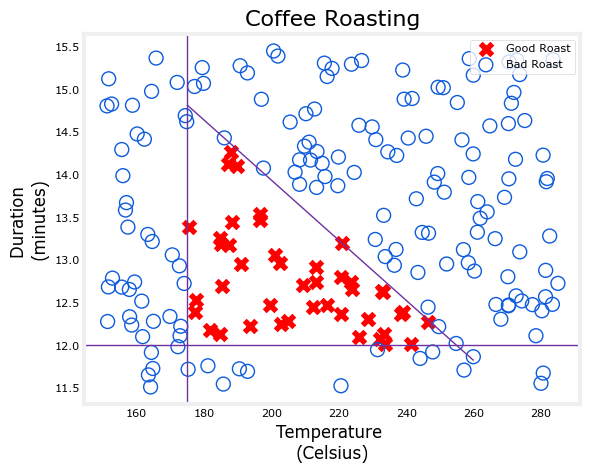

In [3]:
plt_roast(X,Y)

### 数据归一化
为了与之前的实验匹配，我们将对数据进行归一化处理。更多细节请参考该实验。

In [4]:
print(f"Temperature Max, Min pre normalization: {np.max(X[:,0]):0.2f}, {np.min(X[:,0]):0.2f}")
print(f"Duration    Max, Min pre normalization: {np.max(X[:,1]):0.2f}, {np.min(X[:,1]):0.2f}")
norm_l = tf.keras.layers.Normalization(axis=-1)
norm_l.adapt(X)  # learns mean, variance
Xn = norm_l(X)
print(f"Temperature Max, Min post normalization: {np.max(Xn[:,0]):0.2f}, {np.min(Xn[:,0]):0.2f}")
print(f"Duration    Max, Min post normalization: {np.max(Xn[:,1]):0.2f}, {np.min(Xn[:,1]):0.2f}")

Temperature Max, Min pre normalization: 284.99, 151.32
Duration    Max, Min pre normalization: 15.45, 11.51
Temperature Max, Min post normalization: 1.66, -1.69
Duration    Max, Min post normalization: 1.79, -1.70


## Numpy Model (Forward Prop in NumPy)
<center> <img  src="../work/images/C2_W1_RoastingNetwork.PNG" width="200" />   <center/>  
让我们构建课堂上描述的“咖啡烘焙网络”。该网络有两层，采用sigmoid激活函数。

正如课堂中所讲，可以使用NumPy构建自己的全连接层。  
然后，就可以利用这个全连接层构建一个多层神经网络。
<img src="../work/images/C2_W1_dense2.PNG" width="600" height="450">

在第一个选做实验中，你在NumPy和TensorFlow中构建了神经元，并注意到了它们的相似之处。一个层仅仅包含多个神经元/单元。正如课堂中所讲，可以利用for循环遍历层中的每个单元（`j`），计算该单元的权重（`W[:,j]`）的点积，并加上该单元的偏置（`b[j]`）来得到`z`。然后，可以对这个结果应用激活函数`g(z)`。下面让我们尝试构建一个 “全连接层” 子程序。 

In [6]:
def my_dense(a_in, W, b, g):
    """
    Computes dense layer
    Args:
      a_in (ndarray (n, )) : Data, 1 example 
      W    (ndarray (n,j)) : Weight matrix, n features per unit, j units
      b    (ndarray (j, )) : bias vector, j units  
      g    activation function (e.g. sigmoid, relu..)
    Returns
      a_out (ndarray (j,))  : j units|
    """
    units = W.shape[1]
    a_out = np.zeros(units)
    for j in range(units):               
        w = W[:,j]                                    
        z = np.dot(w, a_in) + b[j]         
        a_out[j] = g(z)               
    return(a_out)

以下代码单元使用上述 `my_dense` 子程序构建一个两层神经网络。

In [15]:
def my_sequential(x, W1, b1, W2, b2):
    a1 = my_dense(x,  W1, b1, sigmoid)
    print("a1:", a1)
    a2 = my_dense(a1, W2, b2, sigmoid)
    print("a2:", a2)
    return(a2)

我们可以从之前TensorFlow实验中复制训练好的权重和偏差。

In [16]:
W1_tmp = np.array( [[-8.93,  0.29, 12.9 ], [-0.1,  -7.32, 10.81]] )
b1_tmp = np.array( [-9.82, -9.28,  0.96] )
W2_tmp = np.array( [[-31.18], [-27.59], [-32.56]] )
b2_tmp = np.array( [15.41] )

### Predictions
<img align="left" src="../work/images/C2_W1_RoastingDecision.PNG"     style=" width:380px; padding: 10px 20px; " >

一旦你有了一个训练好的模型，就可以用它来进行预测。请记住，我们模型的输出是一个概率。在这种情况下，是烘焙成功的概率。为了做出决策，必须将该概率与一个阈值进行比较。在这种情况下，我们将使用0.5这个阈值。 

我们先编写一个类似于Tensorflow的`model.predict()`的函数。这个函数将接受一个矩阵$X$，其中$m$个样本按行排列，并通过运行模型进行预测。

In [17]:
def my_predict(X, W1, b1, W2, b2):
    m = X.shape[0]
    p = np.zeros((m,1))
    for i in range(m):
        p[i] = my_sequential(X[i], W1, b1, W2, b2)
    return(p)

我们可以在两个例子上尝试这个程序：

In [18]:
X_tst = np.array([
    [200,13.9],  # postive example
    [200,17]])   # negative example
X_tstn = norm_l(X_tst)  # remember to normalize
predictions = my_predict(X_tstn, W1_tmp, b1_tmp, W2_tmp, b2_tmp)

a1: [3.37e-03 3.88e-06 3.61e-01]
a2: [0.97]
a1: [2.56e-03 7.17e-15 1.00e+00]
a2: [3.29e-08]


为了将概率转化为决策，我们应用一个阈值：

In [19]:
yhat = np.zeros_like(predictions)
for i in range(len(predictions)):
    if predictions[i] >= 0.5:
        yhat[i] = 1
    else:
        yhat[i] = 0
print(f"decisions = \n{yhat}")

decisions = 
[[1.]
 [0.]]


这可以更简洁地完成：

In [20]:
yhat = (predictions >= 0.5).astype(int)
print(f"decisions = \n{yhat}")

decisions = 
[[1]
 [0]]


## Network function

此图展示了整个网络的运行情况，与上一实验中的TensorFlow结果相同。  
左侧的图是由蓝色阴影表示的最后一层的原始输出。这覆盖在由X和O表示的训练数据上。  
右侧的图是经过决策阈值处理后的网络输出。这里的X和O对应于网络做出的决策。

a1: [9.97e-01 9.40e-01 5.72e-18]
a2: [8.65e-19]
a1: [9.93e-01 9.41e-01 1.75e-17]
a2: [9.39e-19]
a1: [9.84e-01 9.42e-01 5.35e-17]
a2: [1.17e-18]
a1: [9.67e-01 9.44e-01 1.63e-16]
a2: [1.95e-18]
a1: [9.31e-01 9.45e-01 5.00e-16]
a2: [5.77e-18]
a1: [8.62e-01 9.46e-01 1.53e-15]
a2: [4.85e-17]
a1: [7.42e-01 9.48e-01 4.67e-15]
a2: [1.97e-15]
a1: [5.70e-01 9.49e-01 1.43e-14]
a2: [4.04e-13]
a1: [3.79e-01 9.50e-01 4.36e-14]
a2: [1.48e-10]
a1: [2.20e-01 9.51e-01 1.33e-13]
a2: [2.07e-08]
a1: [1.15e-01 9.52e-01 4.08e-13]
a2: [5.26e-07]
a1: [5.66e-02 9.54e-01 1.25e-12]
a2: [3.16e-06]
a1: [2.69e-02 9.55e-01 3.81e-12]
a2: [7.74e-06]
a1: [1.26e-02 9.56e-01 1.16e-11]
a2: [1.17e-05]
a1: [5.86e-03 9.57e-01 3.56e-11]
a2: [1.41e-05]
a1: [2.71e-03 9.58e-01 1.09e-10]
a2: [1.51e-05]
a1: [1.25e-03 9.59e-01 3.33e-10]
a2: [1.54e-05]
a1: [5.79e-04 9.60e-01 1.02e-09]
a2: [1.53e-05]
a1: [2.67e-04 9.61e-01 3.11e-09]
a2: [1.5e-05]
a1: [1.23e-04 9.62e-01 9.51e-09]
a2: [1.47e-05]
a1: [5.69e-05 9.63e-01 2.91e-08]
a2: [1.4

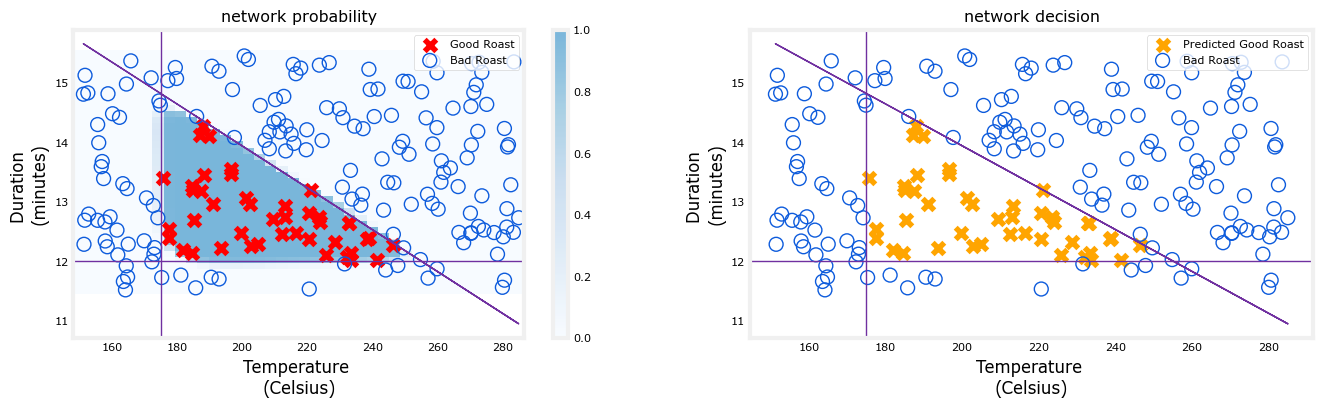

In [21]:
netf= lambda x : my_predict(norm_l(x),W1_tmp, b1_tmp, W2_tmp, b2_tmp)
plt_network(X,Y,netf)

## 恭喜！
你已经用NumPy构建了一个小型神经网络。  
希望这个实验揭示了构成神经网络中一层的相当简单且熟悉的函数。